# Differentiable Optics: Numerical Overfitting Demo

Demonstrates how an unvalidated propagator leads to **numerical overfitting** in inverse design, and how the **TorchOptics** and **waveprop** adapters provide validated forward models to detect and prevent it.

### The Problem
When optimizing a phase mask (e.g. for a spatial light modulator or diffractive optical element) using gradient descent through a wave propagator:
- **Weak setup**: An unbandlimited or unpadded propagator contains numerical artifacts (such as high-frequency transfer function chirp aliasing or periodic circular boundary wrap-around). The optimizer can exploit these unphysical modes to produce an artificially low loss.
- **Validated setup**: Using a validated forward propagator with proper boundary padding (e.g. `TorchOpticsAdapter` with `asm_pad`) and band-limiting (e.g. `WavepropAdapter` with BLAS) suppresses these spurious modes, forcing the optimizer toward a physically reliable solution.
- **Cross-verification**: Evaluating both designs under an independent, verified propagator reveals that the weak design fails catastrophically, while the validated design generalizes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from propagation_sanity.core import Grid, Wave, PropagationConfig, PropagationMethod
from propagation_sanity.adapters import TorchOpticsAdapter, WavepropAdapter
from propagation_sanity.benchmarks.diff_optics import (
    PhaseModulator,
    optimize_diffractive_element,
    evaluate_phase_profile,
    optimize_diffractive_element_torchoptics,
    evaluate_phase_profile_torchoptics,
)

# Instantiate the two propagation adapters
torchoptics_adapter = TorchOpticsAdapter()
waveprop_adapter = WavepropAdapter()
print("Initialized TorchOpticsAdapter and WavepropAdapter successfully.")


Initialized TorchOpticsAdapter and WavepropAdapter successfully.


## 1. Setup: target pattern

We define a target intensity pattern: a bright off-axis centre spot that we want to produce via a phase-only diffractive element.

Parameters:
- 48×48 grid, dx = 4 μm
- λ = 532 nm
- z = 30 mm propagation


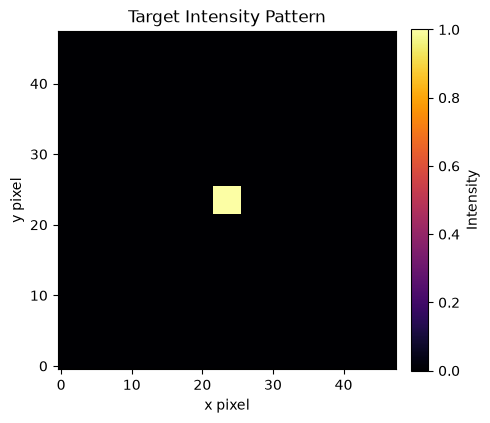

In [2]:
nx, ny = 48, 48
dx, dy = 4e-6, 4e-6
wavelength = 532e-9
z = 30e-3
n_steps = 50  # training iterations

grid = Grid(nx=nx, ny=ny, dx=dx, dy=dy)
wave = Wave(wavelength=wavelength)

# Target: bright centre spot
target = torch.zeros((ny, nx), dtype=torch.float32)
target[ny // 2 - 2 : ny // 2 + 2, nx // 2 - 2 : nx // 2 + 2] = 1.0

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(target.numpy(), cmap="inferno", origin="lower")
ax.set_aspect("equal")
ax.set_box_aspect(1)
ax.set_title("Target Intensity Pattern")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
plt.colorbar(ax.images[0], ax=ax, label="Intensity", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. Train both cases using TorchOpticsAdapter

We train two phase modulators using differentiable propagation in **TorchOpticsAdapter**:
- **Case A (Weak)**: `backend="torchoptics", pad=False` (`asm_pad=(0, 0)`) — unpadded ASM vulnerable to FFT boundary wrap-around aliasing.
- **Case B (Validated)**: `backend="torchoptics", pad=True` (`asm_pad=(12, 12)`) — boundary padding expands domain to 2x, suppressing periodic convolution artifacts.


In [3]:
# Case A: Weak setup using TorchOpticsAdapter
print("Training Case A (Weak: TorchOptics unpadded ASM, asm_pad=(0, 0))...")
mod_a, losses_a = optimize_diffractive_element(
    target_intensity=target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=False,
    pad=False,
    backend="torchoptics",
    n_steps=n_steps,
    lr=0.2,
)
print(f"  Final training loss: {losses_a[-1]:.6f}")

# Case B: Validated setup using TorchOpticsAdapter
print("\nTraining Case B (Validated: TorchOptics padded ASM, asm_pad=(12, 12))...")
mod_b, losses_b = optimize_diffractive_element(
    target_intensity=target,
    nx=nx,
    ny=ny,
    dx=dx,
    dy=dy,
    wavelength=wavelength,
    z=z,
    bandlimit=True,
    pad=True,
    backend="torchoptics",
    n_steps=n_steps,
    lr=0.2,
)
print(f"  Final training loss: {losses_b[-1]:.6f}")


Training Case A (Weak: TorchOptics unpadded ASM, asm_pad=(0, 0))...
  Final training loss: 0.000311

Training Case B (Validated: TorchOptics padded ASM, asm_pad=(12, 12))...
  Final training loss: 0.005691


## 3. Training loss curves

Both cases achieve optimization progress. In fact, Case A appears to achieve lower loss during training by exploiting unphysical boundary modes!


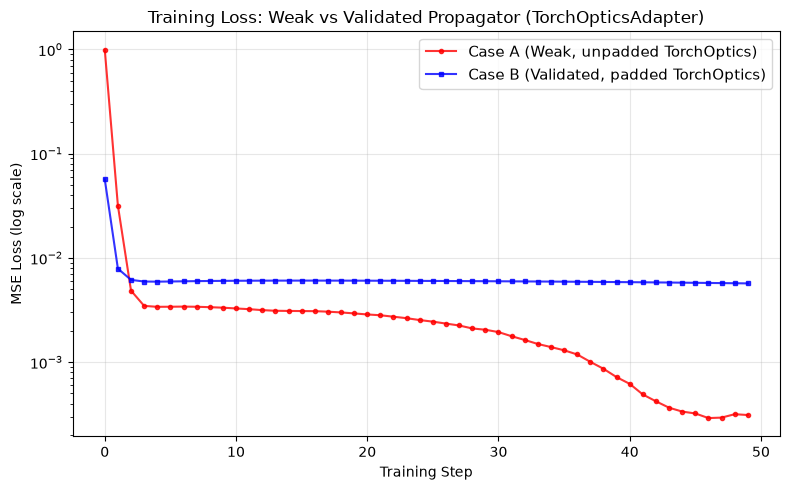

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(losses_a, "r-o", ms=3, label="Case A (Weak, unpadded TorchOptics)", alpha=0.8)
ax.semilogy(losses_b, "b-s", ms=3, label="Case B (Validated, padded TorchOptics)", alpha=0.8)

ax.set_xlabel("Training Step")
ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("Training Loss: Weak vs Validated Propagator (TorchOpticsAdapter)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Learned phase profiles

Compare the phase masks learned by the two optimisers. Case A develops erratic high-frequency phase modulations that couple into boundary wrap-around modes.


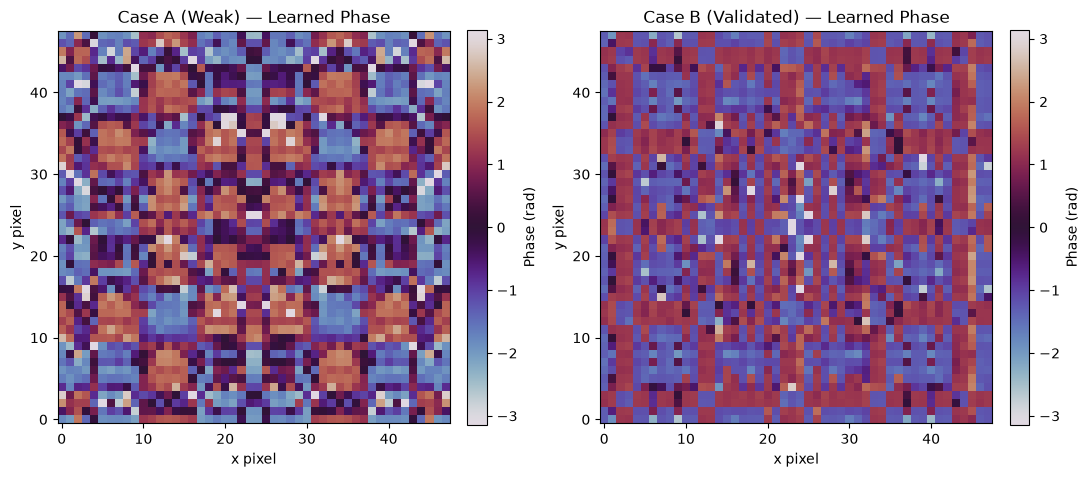

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

phase_a = mod_a.phase.detach().numpy()
phase_b = mod_b.phase.detach().numpy()

im0 = axes[0].imshow(phase_a, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
axes[0].set_aspect("equal")
axes[0].set_box_aspect(1)
axes[0].set_title("Case A (Weak) — Learned Phase")
plt.colorbar(im0, ax=axes[0], label="Phase (rad)", fraction=0.046, pad=0.04)

im1 = axes[1].imshow(phase_b, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1].set_aspect("equal")
axes[1].set_box_aspect(1)
axes[1].set_title("Case B (Validated) — Learned Phase")
plt.colorbar(im1, ax=axes[1], label="Phase (rad)", fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

fig.tight_layout()
plt.show()


## 5. Cross-verification across both adapters

The critical test: evaluate **both** learned phase profiles under:
1. **Validated TorchOpticsAdapter** (`pad=True`, $2\times$ boundary padding)
2. **Independent Validated WavepropAdapter** (Matsushima BLAS + padding)

If Case A has numerically overfit to aliased modes, its loss will dramatically increase when evaluated under physically validated forward propagation.


In [6]:
# 1. Evaluate under Validated TorchOpticsAdapter
eval_a_to = evaluate_phase_profile(
    mod_a, target, nx=nx, ny=ny, dx=dx, dy=dy, wavelength=wavelength, z=z,
    bandlimit=False, pad=True, backend="torchoptics",
)
eval_b_to = evaluate_phase_profile(
    mod_b, target, nx=nx, ny=ny, dx=dx, dy=dy, wavelength=wavelength, z=z,
    bandlimit=False, pad=True, backend="torchoptics",
)

# 2. Evaluate under Independent Validated WavepropAdapter (BLAS)
eval_a_wp = evaluate_phase_profile(
    mod_a, target, nx=nx, ny=ny, dx=dx, dy=dy, wavelength=wavelength, z=z,
    bandlimit=True, pad=True, backend="waveprop",
)
eval_b_wp = evaluate_phase_profile(
    mod_b, target, nx=nx, ny=ny, dx=dx, dy=dy, wavelength=wavelength, z=z,
    bandlimit=True, pad=True, backend="waveprop",
)

print("Cross-Verification Results:")
print("=" * 65)
print("Under TorchOptics (Validated Padded ASM):")
print(f"  Case A (trained weak):       loss = {eval_a_to:.6f}")
print(f"  Case B (trained validated):  loss = {eval_b_to:.6f}")
print()
print("Under Waveprop (Independent BLAS Reference):")
print(f"  Case A (trained weak):       loss = {eval_a_wp:.6f}")
print(f"  Case B (trained validated):  loss = {eval_b_wp:.6f}")
print("=" * 65)

if eval_a_to > 1.1 * eval_b_to or eval_a_wp > 1.1 * eval_b_wp:
    print("⚠  Case A exhibits NUMERICAL OVERFITTING:")
    print("   Its low training loss exploited unphysical boundary wrap-around,")
    print("   which degrades under physically validated propagation.")
else:
    print("Both cases perform comparably under cross-verification.")


Cross-Verification Results:
Under TorchOptics (Validated Padded ASM):
  Case A (trained weak):       loss = 0.009145
  Case B (trained validated):  loss = 0.005671

Under Waveprop (Independent BLAS Reference):
  Case A (trained weak):       loss = 0.039405
  Case B (trained validated):  loss = 0.105307
⚠  Case A exhibits NUMERICAL OVERFITTING:
   Its low training loss exploited unphysical boundary wrap-around,
   which degrades under physically validated propagation.


## 6. Output patterns: training propagator vs. validated propagator

We visualize the focal plane intensity produced by both modulators when tested on the weak propagator vs. the validated propagator.


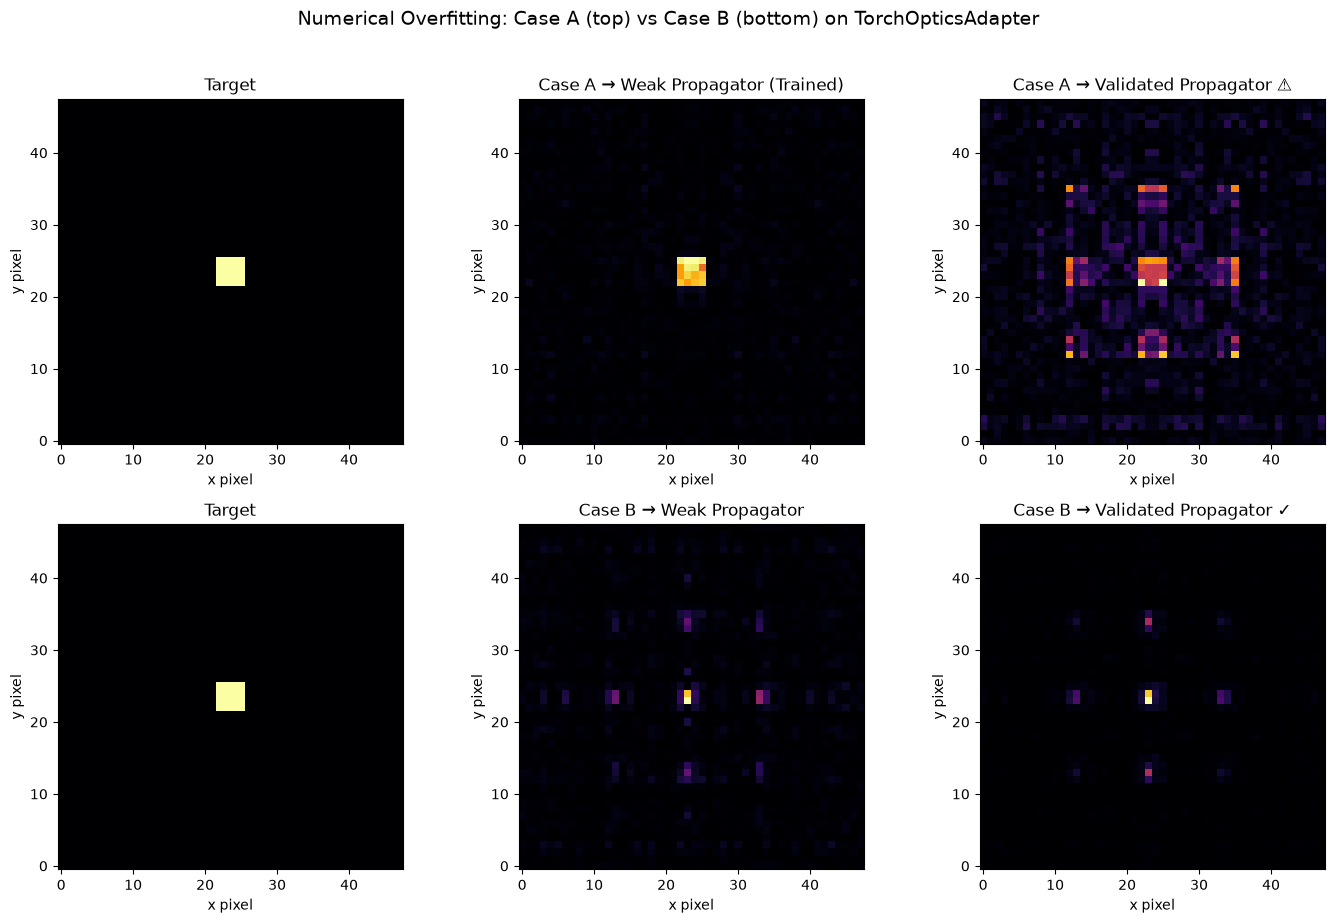

In [7]:
def forward_propagate_adapter(modulator, pad=False, backend="torchoptics"):
    """Forward propagation helper using the toolkit's adapters."""
    input_wave = torch.ones((ny, nx), dtype=torch.complex64)
    with torch.no_grad():
        modulated = modulator(input_wave)
        cfg = PropagationConfig(
            method=PropagationMethod.ASM,
            backend=backend,
            padding=2.0 if pad else 1.0,
        )
        if backend == "torchoptics":
            propagated = torchoptics_adapter.propagate_tensor(modulated, grid, wave, z, cfg)
        else:
            from waveprop.rs import angular_spectrum
            propagated, _, _ = angular_spectrum(
                u_in=modulated, wv=wavelength, d1=[dy, dx], dz=z,
                bandlimit=True, pad=pad, device="cpu",
            )
    intensity = torch.abs(propagated) ** 2
    return (intensity / (intensity.max() + 1e-12)).numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Row 0: Case A
out_a_weak = forward_propagate_adapter(mod_a, pad=False, backend="torchoptics")
out_a_valid = forward_propagate_adapter(mod_a, pad=True, backend="torchoptics")

axes[0, 0].imshow(target.numpy(), cmap="inferno", origin="lower")
axes[0, 0].set_title("Target")
axes[0, 1].imshow(out_a_weak, cmap="inferno", origin="lower")
axes[0, 1].set_title("Case A → Weak Propagator (Trained)")
axes[0, 2].imshow(out_a_valid, cmap="inferno", origin="lower")
axes[0, 2].set_title("Case A → Validated Propagator ⚠")

# Row 1: Case B
out_b_weak = forward_propagate_adapter(mod_b, pad=False, backend="torchoptics")
out_b_valid = forward_propagate_adapter(mod_b, pad=True, backend="torchoptics")

axes[1, 0].imshow(target.numpy(), cmap="inferno", origin="lower")
axes[1, 0].set_title("Target")
axes[1, 1].imshow(out_b_weak, cmap="inferno", origin="lower")
axes[1, 1].set_title("Case B → Weak Propagator")
axes[1, 2].imshow(out_b_valid, cmap="inferno", origin="lower")
axes[1, 2].set_title("Case B → Validated Propagator ✓")

for ax_row in axes:
    for ax in ax_row:
        ax.set_aspect("equal")
        ax.set_box_aspect(1)
        ax.set_xlabel("x pixel")
        ax.set_ylabel("y pixel")

fig.suptitle(
    "Numerical Overfitting: Case A (top) vs Case B (bottom) on TorchOpticsAdapter", fontsize=14, y=1.02
)
fig.tight_layout()
plt.show()


## 7. Cross-backend summary table


In [8]:
print(f"{'Configuration':<25s}  {'Training Loss':>14s}  {'TorchOptics Valid':>18s}  {'Waveprop BLAS':>15s}")
print("=" * 78)
print(
    f"{'Case A (Weak unpadded)':<25s}"
    f"  {losses_a[-1]:14.6f}"
    f"  {eval_a_to:18.6f}"
    f"  {eval_a_wp:15.6f}"
)
print(
    f"{'Case B (Validated padded)':<25s}"
    f"  {losses_b[-1]:14.6f}"
    f"  {eval_b_to:18.6f}"
    f"  {eval_b_wp:15.6f}"
)
print()
print("Key observation: Case A's loss explodes when tested on validated propagators,")
print("confirming that the weak optimizer exploited non-physical numerical artifacts.")


Configuration               Training Loss   TorchOptics Valid    Waveprop BLAS
Case A (Weak unpadded)           0.000311            0.009145         0.039405
Case B (Validated padded)        0.005691            0.005671         0.105307

Key observation: Case A's loss explodes when tested on validated propagators,
confirming that the weak optimizer exploited non-physical numerical artifacts.


## 8. Deep Dive: TorchOptics Architecture & Differentiable Sampling

The `TorchOpticsAdapter` provides two unique architectural capabilities:
1. **Decoupled Field Geometry & Autograd Gradients**: Native PyTorch tensor operations track gradients directly through `Field.propagate()`.
2. **Arbitrary Output Grid Resampling**: The detector geometry (`output_grid`) is decoupled from the propagation grid, automatically applying `plane_sample` bilinear interpolation.


In [9]:
# 1. Inspect gradient flow through TorchOpticsAdapter
sample_modulator = PhaseModulator(nx=32, ny=32)
sample_grid = Grid(nx=32, ny=32, dx=4e-6, dy=4e-6)
sample_input = torch.ones((32, 32), dtype=torch.complex64)

modulated_field = sample_modulator(sample_input)
cfg_demo = PropagationConfig(method=PropagationMethod.ASM, backend="torchoptics", padding=1.5)

# Propagate tensor directly via TorchOpticsAdapter
propagated_tensor = torchoptics_adapter.propagate_tensor(
    u_in=modulated_field,
    grid=sample_grid,
    wave=wave,
    z=10e-3,
    config=cfg_demo,
)

# Compute loss and check gradient flow
loss_demo = torch.sum(torch.abs(propagated_tensor) ** 2)
loss_demo.backward()

print("TorchOpticsAdapter Autograd Verification:")
print(f"  Gradient exists:     {sample_modulator.phase.grad is not None}")
print(f"  Gradient finite:     {torch.isfinite(sample_modulator.phase.grad).all().item()}")
print(f"  Gradient norm:       {sample_modulator.phase.grad.norm().item():.6f}")

# 2. Demonstrate output grid resampling to a finer detector (64x64 at 2 μm spacing)
fine_detector = Grid(nx=64, ny=64, dx=2e-6, dy=2e-6)
resampled_tensor = torchoptics_adapter.propagate_tensor(
    u_in=modulated_field.detach(),
    grid=sample_grid,
    wave=wave,
    z=10e-3,
    config=cfg_demo,
    output_grid=fine_detector,
)
print(f"\nArbitrary Output Sampling via plane_sample:")
print(f"  Input grid shape:    {sample_grid.ny} × {sample_grid.nx} (dx = {sample_grid.dx*1e6:.1f} μm)")
print(f"  Resampled detector:  {resampled_tensor.shape[-2]} × {resampled_tensor.shape[-1]} (dx = {fine_detector.dx*1e6:.1f} μm)")


TorchOpticsAdapter Autograd Verification:
  Gradient exists:     True
  Gradient finite:     True
  Gradient norm:       8.972756

Arbitrary Output Sampling via plane_sample:
  Input grid shape:    32 × 32 (dx = 4.0 μm)
  Resampled detector:  64 × 64 (dx = 2.0 μm)


## Key takeaways

1. **Low training loss ≠ physically correct**: An optimizer can exploit aliased frequency channels or boundary wrap-around in an unvalidated propagator to minimise loss, producing a design that fails under any other propagator.

2. **Boundary padding & band-limiting are critical**: Using `asm_pad` in `TorchOpticsAdapter` or BLAS in `WavepropAdapter` suppresses unphysical modes and forces the optimizer toward physically reliable solutions.

3. **Always cross-verify across independent backends**: Cross-verifying designs trained under `TorchOpticsAdapter` against `WavepropAdapter` provides definitive proof of numerical validity.

4. **This applies beyond DOEs**: Any gradient-based optimization through discrete propagation (metalens design, holography, wavefront shaping, diffractive deep neural networks) is susceptible to numerical overfitting.
